In [23]:
import pandas as pd
import matplotlib.pyplot as plt



In [24]:
pd.options.display.max_rows=6 #show only 5 rows of output
internet=pd.read_csv('./data/world-internet-users.csv')
internet

,year,internet_users
0,1990,3000000
1,1991,4000000
2,1992,7000000
...,...,...
32,2022,5300000000
33,2023,5400000000
34,2024,5450000000


There are 35 rows of data,representing the years from 1990 to 2024


In [25]:
exceeds_100M = internet.query('internet_users > 100e6')
exceeds_100M.head(1)

,year,internet_users
7,1997,120000000


Internet users went from 3 millions in 1990 to over 100 million in 7 years

In [26]:
population = pd.read_csv('./data/historical-world-population.csv')
population

,year,population
0,-10000,4501152
1,-9000,5687125
2,-8000,7314623
...,...,...
122,2020,7887001284
123,2021,7954448405
124,2022,8021407170


Let's merge both dataframes together so we have both population and internet_users columns in one structure

In [27]:
df = pd.merge(internet,population,on='year',how='left')
df

,year,internet_users,population
0,1990,3000000,5.327803e+09
1,1991,4000000,5.418736e+09
2,1992,7000000,5.505990e+09
...,...,...,...
32,2022,5300000000,8.021407e+09
33,2023,5400000000,NaN
34,2024,5450000000,NaN


There are 35 years of internet_user data, but the last two rows have population values is NaN.
Let's drop these incomplete rows.

In [28]:
df = df.dropna()
df

,year,internet_users,population
0,1990,3000000,5.327803e+09
1,1991,4000000,5.418736e+09
2,1992,7000000,5.505990e+09
...,...,...,...
30,2020,4700000000,7.887001e+09
31,2021,4901000000,7.954448e+09
32,2022,5300000000,8.021407e+09


Now, we calculate the percent of the global population connected to the internet for each year.

In [29]:
df['percent'] = df.eval('internet_users/population * 100')
df['percent'] = df['percent'].round(2)
df

,year,internet_users,population,percent
0,1990,3000000,5.327803e+09,0.06
1,1991,4000000,5.418736e+09,0.07
2,1992,7000000,5.505990e+09,0.13
...,...,...,...,...
30,2020,4700000000,7.887001e+09,59.59
31,2021,4901000000,7.954448e+09,61.61
32,2022,5300000000,8.021407e+09,66.07


In 1990 less than 0.1% of the world used the internet, but by 2022 over 65% were connected.

Let's plot the percentage of Internet users over time. We will use axhline() method to draw a horizontal axis line at the 50% mark. This will give us a visual estimate of when internet use first passed 50%


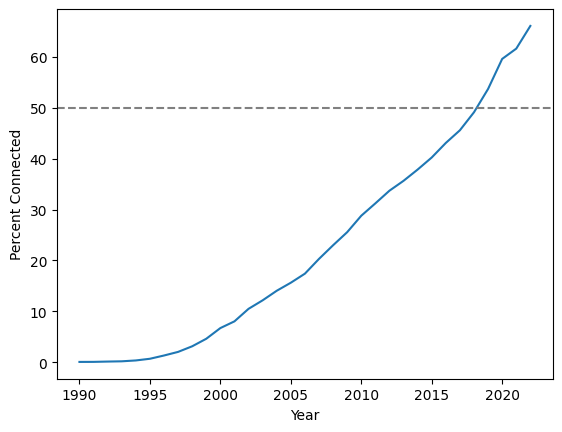

In [30]:
import matplotlib.pyplot as plt
plt.plot(df['year'],df['percent'])
plt.axhline(50, color='grey', linestyle='--')
plt.xlabel('Year')
plt.ylabel('Percent Connected')
plt.show()

Now we'll find the year we crossed 50%

In [31]:
half_connectd = df.query('percent >=50')
half_connectd.head(1)

,year,internet_users,population,percent
29,2019,4194000000,7.811294e+09,53.69


The first year to surpass 50% was 2019

## Now we have two dataset one is Internet user by Continent and Total population of each year in each continent

In [32]:
internet_user_by_continent = pd.read_csv('./data/extension-internet-users-by-continent.csv')
internet_user_by_continent

,continent,year,internet_users
0,Africa,1990,0.000000e+00
1,Africa,1991,5.537650e+03
2,Africa,1992,1.649741e+04
...,...,...,...
189,South America,2019,2.815900e+08
190,South America,2020,3.102178e+08
191,South America,2021,3.177395e+08


In [33]:
population_by_continent = pd.read_csv('./data/extension-historical-population-by-continent.csv')
population_by_continent

,continent,year,population
0,Africa,-10000,1118546
1,Africa,-9000,1214579
2,Africa,-8000,1355402
...,...,...,...
1587,South America,2021,428331420
1588,South America,2022,430492814
1589,South America,2023,433024230


We will merge the both table on the basis of year

In [34]:
df1 = pd.merge(internet_user_by_continent,population_by_continent, on=['year','continent'],how='inner')
df1

,continent,year,internet_users,population
0,Africa,1990,0.000000e+00,643775320
1,Africa,1991,5.537650e+03,661103806
2,Africa,1992,1.649741e+04,678558076
...,...,...,...,...
189,South America,2019,2.815900e+08,423548289
190,South America,2020,3.102178e+08,426213551
191,South America,2021,3.177395e+08,428331420


Now we find the percentage of internet users in each continent


In [ ]:
df1['percent'] = df1.eval('internet_users/population * 100')

df1

,continent,year,internet_users,population,percent
0,Africa,1990,0.000000e+00,643775320,0.000000
1,Africa,1991,5.537650e+03,661103806,0.000838
2,Africa,1992,1.649741e+04,678558076,0.002431
...,...,...,...,...,...
189,South America,2019,2.815900e+08,423548289,66.483565
190,South America,2020,3.102178e+08,426213551,72.784598
191,South America,2021,3.177395e+08,428331420,74.180764


##  Visualization: Internet Usage Trends

This graph represents the percentage of internet users across different continents over time.

- The **X-axis** represents the year.
- The **Y-axis** represents the percentage of internet users.
- Each line corresponds to a different continent.
- The legend helps identify each continent.

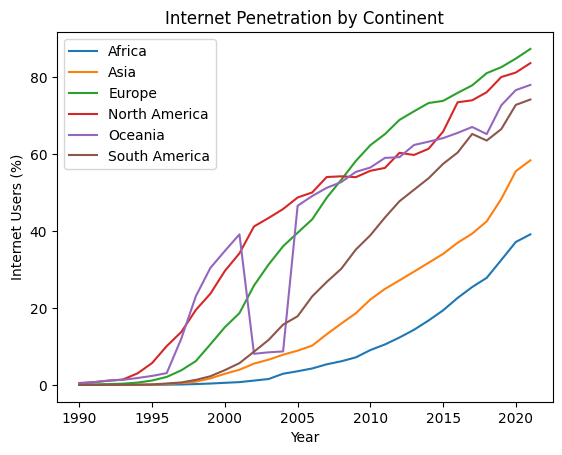

In [55]:
plt.figure()

for c in df1['continent'].unique():
    temp = df1[df1['continent'] == c]
    plt.plot(temp['year'], temp['percent'], label=c)

plt.legend()
plt.title("Internet Penetration by Continent")
plt.xlabel("Year")
plt.ylabel("Internet Users (%)")
plt.show()